In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('Walmart.csv')

In [33]:
print(data.head())

   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  


In [34]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB
None


In [35]:
print(data.describe())

             Store  Weekly_Sales  Holiday_Flag  Temperature   Fuel_Price  \
count  6435.000000  6.435000e+03   6435.000000  6435.000000  6435.000000   
mean     23.000000  1.046965e+06      0.069930    60.663782     3.358607   
std      12.988182  5.643666e+05      0.255049    18.444933     0.459020   
min       1.000000  2.099862e+05      0.000000    -2.060000     2.472000   
25%      12.000000  5.533501e+05      0.000000    47.460000     2.933000   
50%      23.000000  9.607460e+05      0.000000    62.670000     3.445000   
75%      34.000000  1.420159e+06      0.000000    74.940000     3.735000   
max      45.000000  3.818686e+06      1.000000   100.140000     4.468000   

               CPI  Unemployment  
count  6435.000000   6435.000000  
mean    171.578394      7.999151  
std      39.356712      1.875885  
min     126.064000      3.879000  
25%     131.735000      6.891000  
50%     182.616521      7.874000  
75%     212.743293      8.622000  
max     227.232807     14.313000  


In [36]:
# convert date
data['Date'] = pd.to_datetime(data['Date'], format='%d-%m-%Y')

# check missing
print(data.isnull().sum())

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


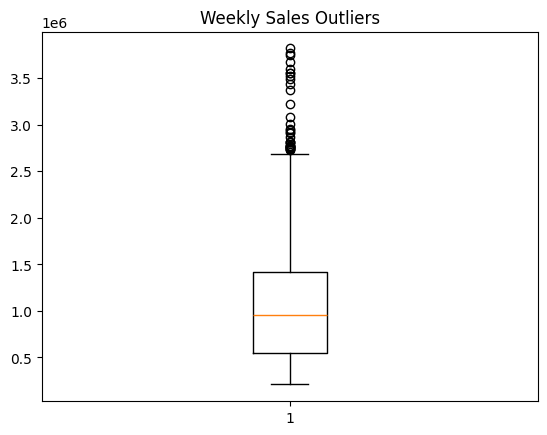

In [37]:
# simple outlier check
plt.boxplot(data['Weekly_Sales'])
plt.title('Weekly Sales Outliers')
plt.show()

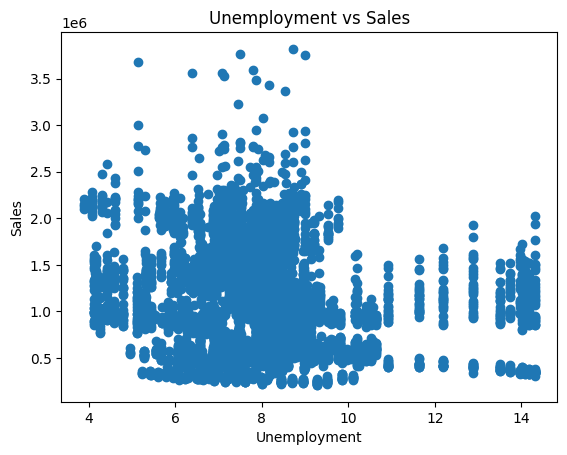

              Weekly_Sales  Unemployment
Weekly_Sales      1.000000     -0.106176
Unemployment     -0.106176      1.000000


In [38]:
# relation between unemployment and sales
plt.scatter(data['Unemployment'], data['Weekly_Sales'])
plt.xlabel('Unemployment')
plt.ylabel('Sales')
plt.title('Unemployment vs Sales')
plt.show()

# correlation
print(data[['Weekly_Sales','Unemployment']].corr())

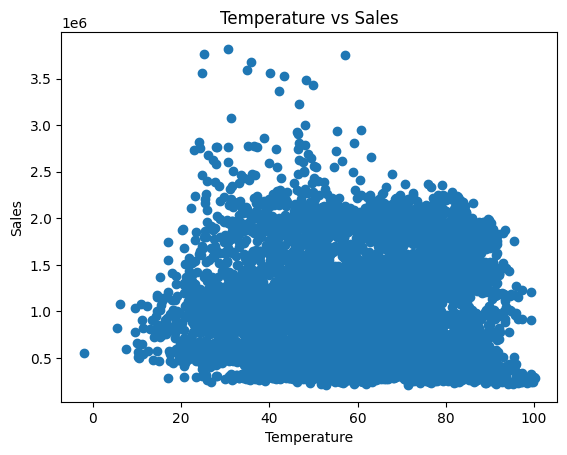

In [39]:
plt.scatter(data['Temperature'], data['Weekly_Sales'])
plt.xlabel('Temperature')
plt.ylabel('Sales')
plt.title('Temperature vs Sales')
plt.show()

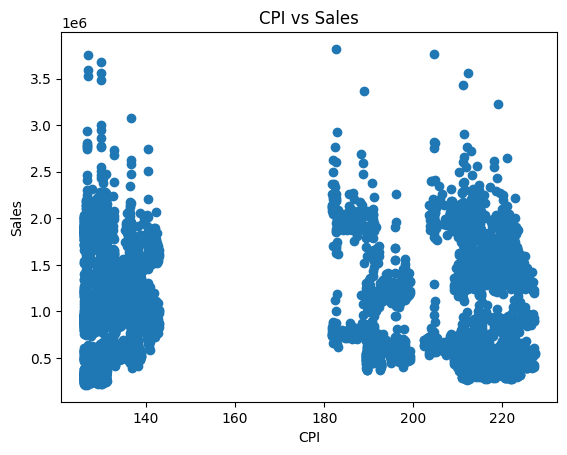

In [40]:
plt.scatter(data['CPI'], data['Weekly_Sales'])
plt.xlabel('CPI')
plt.ylabel('Sales')
plt.title('CPI vs Sales')
plt.show()

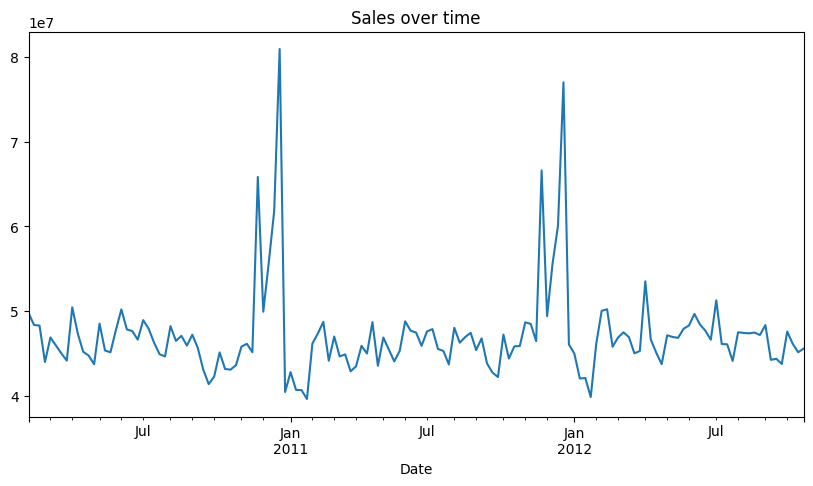

In [41]:
# group by date
sales = data.groupby('Date')['Weekly_Sales'].sum()

# plot
sales.plot(figsize=(10,5), title='Sales over time')
plt.show()

In [42]:
store_sales = data.groupby('Store')['Weekly_Sales'].sum()

# top stores
top = store_sales.sort_values(ascending=False)
print(top.head())

# worst store
worst = store_sales.sort_values().head()
print(worst)

# difference
diff = top.iloc[0] - worst.iloc[0]
print("Difference:", diff)

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
Name: Weekly_Sales, dtype: float64
Store
33    37160221.96
44    43293087.84
5     45475688.90
36    53412214.97
38    55159626.42
Name: Weekly_Sales, dtype: float64
Difference: 264237570.49999997


c:\Users\vsail\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\vsail\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\vsail\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


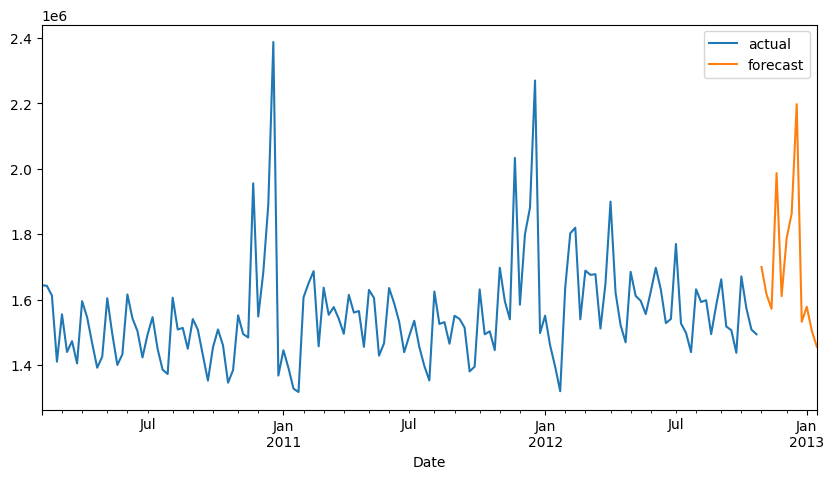

In [43]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# pick one store
store1 = data[data['Store'] == 1]

# group
ts = store1.groupby('Date')['Weekly_Sales'].sum()

# model
model = SARIMAX(ts, order=(1,1,1), seasonal_order=(1,1,1,52))
result = model.fit()

# forecast next 12 weeks
forecast = result.get_forecast(steps=12)
pred = forecast.predicted_mean

# plot
ts.plot(label='actual', figsize=(10,5))
pred.plot(label='forecast')
plt.legend()
plt.show()

In [44]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 1a. Unemployment impact by store
store_unemp_corr = data.groupby('Store').apply(lambda df: df['Weekly_Sales'].corr(df['Unemployment'])).rename('Unemployment_corr')
store_unemp_corr = store_unemp_corr.sort_values()
print('Most negative unemployment effect (more hurt by unemployment):')
print(store_unemp_corr.head(5))
print('\nLeast negative/positive unemployment effect:')
print(store_unemp_corr.tail(5))

Most negative unemployment effect (more hurt by unemployment):
Store
38   -0.785290
44   -0.780076
39   -0.384681
42   -0.356355
41   -0.350630
Name: Unemployment_corr, dtype: float64

Least negative/positive unemployment effect:
Store
30    0.201862
14    0.210786
21    0.218367
35    0.483865
36    0.833734
Name: Unemployment_corr, dtype: float64


C:\Users\vsail\AppData\Local\Temp\ipykernel_9440\661848800.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  store_unemp_corr = data.groupby('Store').apply(lambda df: df['Weekly_Sales'].corr(df['Unemployment'])).rename('Unemployment_corr')


Seasonality component preview:
Date
2010-02-08    1.354832e+05
2010-02-15    1.365437e+06
2010-02-22    1.863852e+06
2010-03-01   -2.583723e+06
2010-03-08   -3.064306e+05
Freq: W-MON, Name: seasonal, dtype: float64


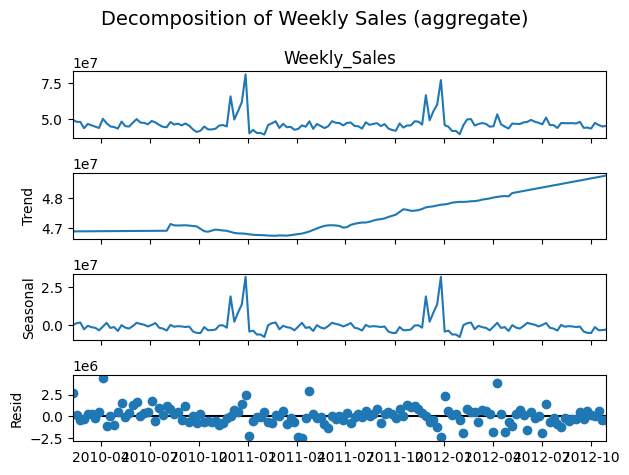

In [45]:
# 1b. Seasonality check (aggregate)
weekly_sales = data.set_index('Date').sort_index().resample('W-MON')['Weekly_Sales'].sum()
decomp = seasonal_decompose(weekly_sales, model='additive', period=52, extrapolate_trend='freq')
print('Seasonality component preview:')
print(decomp.seasonal.head())

decomp.plot().suptitle('Decomposition of Weekly Sales (aggregate)', fontsize=14)
plt.tight_layout()
plt.show()

In [46]:
# 1c. Temperature effect by store
store_temp_corr = data.groupby('Store').apply(lambda df: df['Weekly_Sales'].corr(df['Temperature'])).rename('Temperature_corr')
store_temp_corr = store_temp_corr.sort_values()
print('Temperature correlations by store:')
print(store_temp_corr.head(5))
print(store_temp_corr.tail(5))

Temperature correlations by store:
Store
10   -0.432569
12   -0.379416
3    -0.377524
28   -0.376506
30   -0.330816
Name: Temperature_corr, dtype: float64
Store
24    0.111833
27    0.121809
16    0.182948
26    0.211722
44    0.267822
Name: Temperature_corr, dtype: float64


C:\Users\vsail\AppData\Local\Temp\ipykernel_9440\2509165276.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  store_temp_corr = data.groupby('Store').apply(lambda df: df['Weekly_Sales'].corr(df['Temperature'])).rename('Temperature_corr')


In [47]:
# 1d. CPI effect by store
store_cpi_corr = data.groupby('Store').apply(lambda df: df['Weekly_Sales'].corr(df['CPI'])).rename('CPI_corr')
store_cpi_corr = store_cpi_corr.sort_values()
print('CPI correlations by store:')
print(store_cpi_corr.head(5))
print(store_cpi_corr.tail(5))

CPI correlations by store:
Store
36   -0.915095
35   -0.424107
14   -0.419755
30   -0.298188
43   -0.285686
Name: CPI_corr, dtype: float64
Store
42    0.360859
41    0.392293
39    0.428043
44    0.740150
38    0.812837
Name: CPI_corr, dtype: float64


C:\Users\vsail\AppData\Local\Temp\ipykernel_9440\2024054421.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  store_cpi_corr = data.groupby('Store').apply(lambda df: df['Weekly_Sales'].corr(df['CPI'])).rename('CPI_corr')


In [48]:
# 1e/1f. Top and worst stores with significance
store_sales = data.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
top_store = store_sales.idxmax(); top_value = store_sales.max()
worst_store = store_sales.idxmin(); worst_value = store_sales.min()
print(f'Best store: {top_store} total sales={top_value}')
print(f'Worst store: {worst_store} total sales={worst_value}')
print(f'Difference: {top_value - worst_value} ({(top_value - worst_value)/worst_value:.2%})')

Best store: 20 total sales=301397792.46
Worst store: 33 total sales=37160221.96
Difference: 264237570.49999997 (711.08%)


In [49]:
# 2a. Forecast imports and sample series
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import statsmodels.api as sm

store_sample = data[data['Store'] == 1].set_index('Date').sort_index().resample('W-MON')['Weekly_Sales'].sum()
print('Sample store 1 weekly points:', len(store_sample))

Sample store 1 weekly points: 143


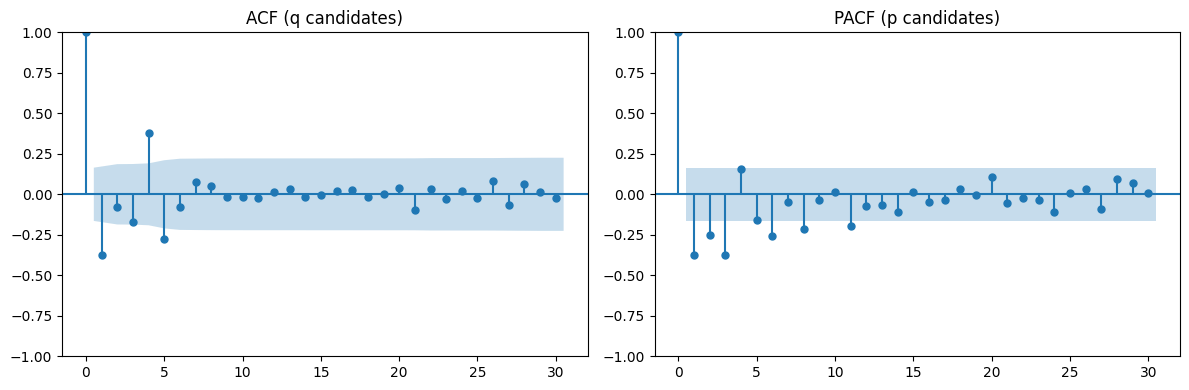

Interpretation:
- ACF significant lag spikes -> consider MA(q).
- PACF significant lag spikes -> consider AR(p).
- d=1 implies first differencing for trend removal.


In [50]:
# 2b. ACF/PACF plots 
fig = plt.figure(figsize=(12,4))
ax1 = fig.add_subplot(121)
sm.graphics.tsa.plot_acf(store_sample.diff().dropna(), lags=30, ax=ax1)
ax1.set_title('ACF (q candidates)')
ax2 = fig.add_subplot(122)
sm.graphics.tsa.plot_pacf(store_sample.diff().dropna(), lags=30, ax=ax2)
ax2.set_title('PACF (p candidates)')
plt.tight_layout()
plt.show()

print('Interpretation:')
print('- ACF significant lag spikes -> consider MA(q).')
print('- PACF significant lag spikes -> consider AR(p).')
print('- d=1 implies first differencing for trend removal.')

In [51]:
# 2c. Forecast function

def forecast_store_sales(series, steps=12):
    model = ExponentialSmoothing(series, trend='add', seasonal='add', seasonal_periods=52)
    fitted = model.fit(optimized=True)
    return fitted.forecast(steps)

print('Defined forecast_store_sales()')

Defined forecast_store_sales()


In [52]:
# 2d. Forecast for each store (loop)
all_forecasts = []
for store_id in sorted(data['Store'].unique()):
    series = data[data['Store'] == store_id].set_index('Date').sort_index().resample('W-MON')['Weekly_Sales'].sum()
    if len(series) < 52:
        print(f'Store {store_id} has only {len(series)} weeks, skipping forecast.')
        continue

    pred = forecast_store_sales(series, steps=12)
    forecast_dates = pd.date_range(start=series.index[-1] + pd.Timedelta(7, 'd'), periods=12, freq='W-MON')
    all_forecasts.append(pd.DataFrame({'Store': store_id, 'Date': forecast_dates, 'Forecast_Weekly_Sales': pred.values}))

print('Forecasting loop complete')

Forecasting loop complete


In [53]:
# 2e. Combine outputs and show results
all_forecasts_df = pd.concat(all_forecasts, ignore_index=True)
print('Stores with forecasts:', all_forecasts_df['Store'].nunique())
print(all_forecasts_df.head(12))

Stores with forecasts: 45
    Store       Date  Forecast_Weekly_Sales
0       1 2012-11-05           1.690366e+06
1       1 2012-11-12           1.618977e+06
2       1 2012-11-19           1.594760e+06
3       1 2012-11-26           2.073036e+06
4       1 2012-12-03           1.653538e+06
5       1 2012-12-10           1.811618e+06
6       1 2012-12-17           1.983270e+06
7       1 2012-12-24           2.450583e+06
8       1 2012-12-31           1.503144e+06
9       1 2013-01-07           1.573173e+06
10      1 2013-01-14           1.508815e+06
11      1 2013-01-21           1.445050e+06


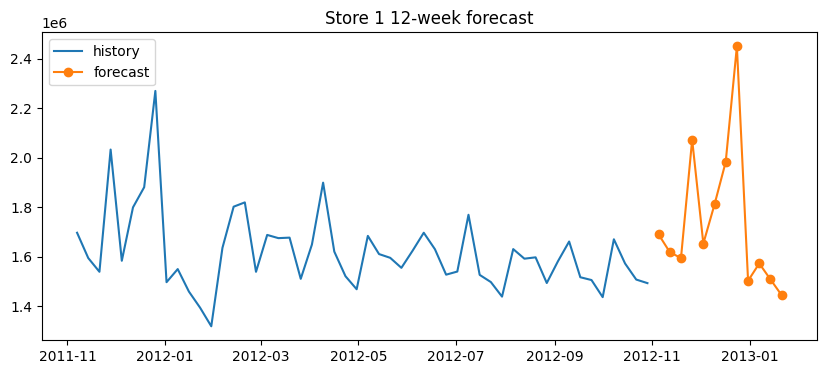

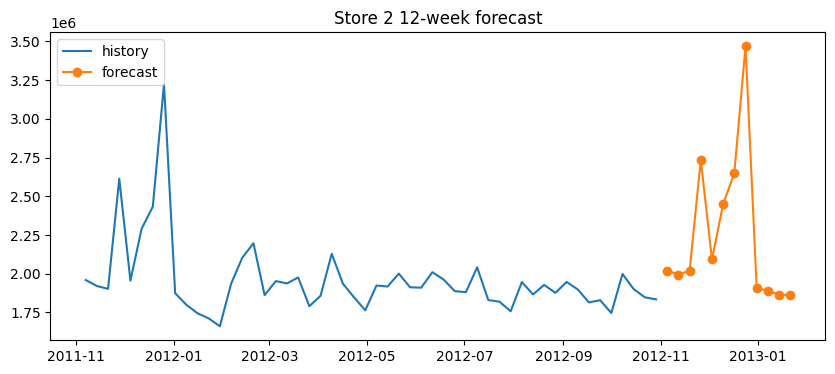

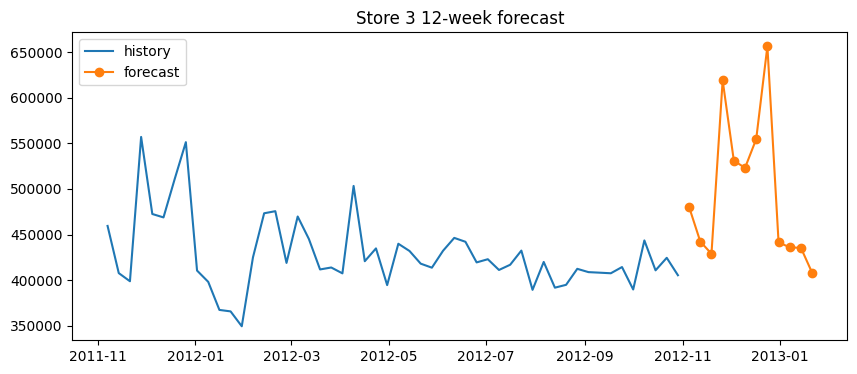

In [54]:
for store_id in [1, 2, 3][:min(3, len(store_sales))]:
    subset = all_forecasts_df[all_forecasts_df['Store'] == store_id]
    history = data[data['Store'] == store_id].set_index('Date').sort_index().resample('W-MON')['Weekly_Sales'].sum()
    plt.figure(figsize=(10,4))
    plt.plot(history[-52:], label='history')
    plt.plot(subset['Date'], subset['Forecast_Weekly_Sales'], marker='o', label='forecast')
    plt.title(f'Store {store_id} 12-week forecast')
    plt.legend()
    plt.show()